# N15 — Pit Stop Duration Model

Pit stop duration is one of the few race variables that's **fully controllable by the team** — and also one where a 2-second mistake can cost a position. This notebook builds a quantile regression model that predicts the P10/P50/P90 distribution of pit stop duration for a given car, compound, circuit, and race context.

**Why quantile regression?** Pit durations are bimodal: clean stops cluster around 23–26 s, while slow stops (traffic, equipment issues, unsafe release) pull the tail out to 35+ s. A single-point estimate misses this; the P10/P90 interval gives the Strategy Agent a realistic best/worst-case window.

**Data source:** FastF1 `laps.PitInTime` / `laps.PitOutTime` (2023–2025 races), giving ~1,500–2,000 usable pit stops after filtering telemetry artifacts.

## Notebook structure

| Step | Content |
|------|---------|
| 0 | Setup + FastF1 download + EDA (distributions, outlier inspection) |
| 1 | Feature engineering + filter bad stops (< 15 s or > 60 s) |
| 2 | Baseline — median by team × circuit |
| 3 | HistGradientBoostingRegressor P10 / P50 / P90 |
| 4 | Evaluation (MAE P50, pinball loss P10/P90) + residuals + feature importance |
| 5 | Export — `hist_pit_p10_v1.pkl`, `hist_pit_p50_v1.pkl`, `hist_pit_p90_v1.pkl`, `model_config.json` |

**Target variable:** `pit_duration_s = PitOutTime − PitInTime` (seconds)


---

In [11]:
# ── Step 0 · Setup + FastF1 pit data download ─────────────────────────────
import sys
from pathlib import Path
repo_root = Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder




In [2]:
CACHE_DIR  = repo_root / "data" / "cache" / "fastf1"
EXPORT_DIR = repo_root / "data" / "models" / "pit_prediction"
PROC_DIR   = repo_root / "data" / "processed" / "pit_labeled"
OUTPUTS    = repo_root / "notebooks" / "strategy" / "pit_prediction" / "outputs"

for d in [CACHE_DIR, EXPORT_DIR, PROC_DIR, OUTPUTS]:
    d.mkdir(parents=True, exist_ok=True)

fastf1.Cache.enable_cache(str(CACHE_DIR))

In [3]:
YEARS = [2023, 2024, 2025]

def collect_pit_data(years):
    records = []
    for year in years:
        schedule = fastf1.get_event_schedule(year, include_testing=False)
        gp_names = schedule[schedule["EventFormat"] != "testing"]["EventName"].tolist()
        for gp in gp_names:
            try:
                session = fastf1.get_session(year, gp, "R")
                session.load(laps=True, telemetry=False, weather=False, messages=False)
            except Exception as e:
                print(f"  SKIP {year} {gp}: {e}")
                continue

            laps = session.laps[["Driver", "Team", "LapNumber", "Compound",
                                  "TyreLife", "PitInTime", "PitOutTime"]].copy()

            pit_in  = laps[laps["PitInTime"].notna()][
                ["Driver", "Team", "LapNumber", "Compound", "TyreLife", "PitInTime"]
            ].copy()
            pit_out = laps[laps["PitOutTime"].notna()][
                ["Driver", "LapNumber", "PitOutTime"]
            ].copy()

            # PitInTime is on lap N, PitOutTime always on lap N+1
            pit_in["LapNumber_out"] = pit_in["LapNumber"] + 1
            merged = pit_in.merge(
                pit_out.rename(columns={"LapNumber": "LapNumber_out"}),
                on=["Driver", "LapNumber_out"], how="inner"
            )
            merged["pit_duration_s"] = (
                merged["PitOutTime"] - merged["PitInTime"]
            ).dt.total_seconds()
            merged["Year"]    = year
            merged["GP_Name"] = gp

            cols = ["Year", "GP_Name", "Team", "Driver", "LapNumber",
                    "Compound", "TyreLife", "pit_duration_s"]
            records.append(merged[cols])
            print(f"  {year} {gp}: {len(merged)} pit stops")

    return pd.concat(records, ignore_index=True)

In [4]:
df_raw = collect_pit_data(YEARS)
print(f"\nTotal raw pit stops: {len(df_raw)}")
print(df_raw["pit_duration_s"].describe())

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data

  2023 Bahrain Grand Prix: 50 pit stops


req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']
core           INFO 	Loading data for Australian Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


  2023 Saudi Arabian Grand Prix: 24 pit stops


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core           INFO 	Finished loading data for 20 drivers: ['1', '44', '14', '18', '11', '4', '27', '81', '24', '22', '77', '55', '10', '31', '21', '2', '20', '63', '23', '16']
core           INFO 	Loading data for Azerbaijan Grand Prix - Race [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for tim

...

  2025 Las Vegas Grand Prix: 23 pit stops


Request for URL https://api.jolpi.ca/ergast/f1/2025/23/results.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\requests_cache\session.py", line 297, in _resend
    response.raise_for_status()
  File "c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\requests\models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/23/results.json
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core         

  2025 Qatar Grand Prix: 41 pit stops


Request for URL https://api.jolpi.ca/ergast/f1/2025/24/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\requests_cache\session.py", line 297, in _resend
    response.raise_for_status()
  File "c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\requests\models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2025/24/laps/1.json
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


  2025 Abu Dhabi Grand Prix: 27 pit stops

Total raw pit stops: 2556
count    2556.000000
mean      113.765811
std       381.980757
min        12.783000
25%        21.835500
50%        23.579000
75%        28.101750
max      2485.909000
Name: pit_duration_s, dtype: float64


## Step 0 · Raw data overview

Collected **2,556 pit stop records** across 2023–2025 (raw, before filtering).

| Metric | Value |
|--------|-------|
| Median duration | 23.6 s |
| P25 / P75 | 21.8 s / 28.1 s |
| Max (raw) | 2,485 s ← data artifact |
| Mean (raw) | 113.8 s ← skewed by extremes |

The interquartile range (21–28 s) matches real-world F1 pit stop timing.
Extreme values (> 60 s) correspond to retirements in the pit lane or laps where
FastF1 assigns a mismatched PitOutTime. These will be filtered in Step 1.


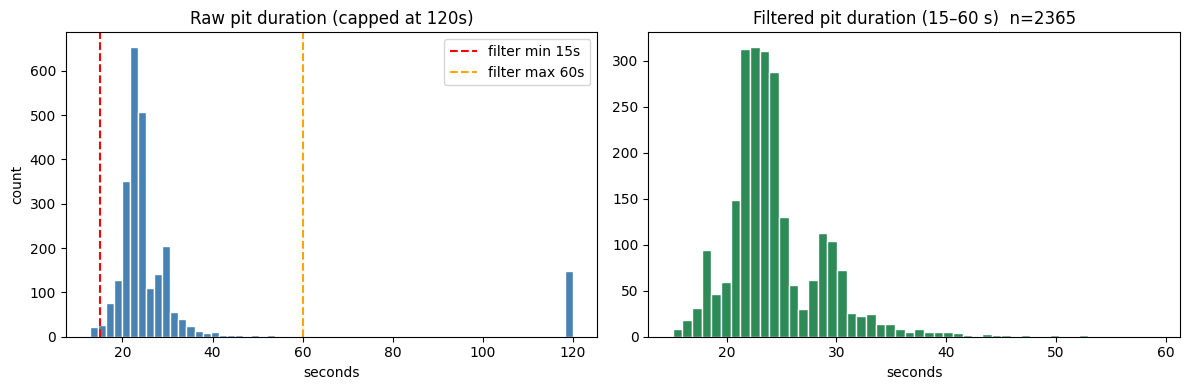

Raw stops:     2556
After filter:  2365
Removed:       191 (7.5%)

count    2365.000000
mean       24.417560
std         4.704625
min        15.062000
25%        21.783000
50%        23.396000
75%        25.687000
max        59.099000
Name: pit_duration_s, dtype: float64


In [5]:
def plot_pit_duration_eda(df_raw, clean, outputs_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(df_raw["pit_duration_s"].clip(upper=120), bins=60,
                 color="steelblue", edgecolor="white")
    axes[0].axvline(15, color="red",    linestyle="--", label="filter min 15s")
    axes[0].axvline(60, color="orange", linestyle="--", label="filter max 60s")
    axes[0].set_title("Raw pit duration (capped at 120s)")
    axes[0].set_xlabel("seconds")
    axes[0].set_ylabel("count")
    axes[0].legend()

    axes[1].hist(clean["pit_duration_s"], bins=50, color="seagreen", edgecolor="white")
    axes[1].set_title(f"Filtered pit duration (15–60 s)  n={len(clean)}")
    axes[1].set_xlabel("seconds")

    plt.tight_layout()
    plt.savefig(outputs_path / "pit_duration_raw_eda.png", dpi=150, bbox_inches="tight")
    plt.show()


def filter_pit_stops(df_raw, min_s=15, max_s=60):
    return df_raw[(df_raw["pit_duration_s"] >= min_s) & (df_raw["pit_duration_s"] <= max_s)].copy()


def print_filter_summary(df_raw, clean):
    print(f"Raw stops:     {len(df_raw)}")
    print(f"After filter:  {len(clean)}")
    print(f"Removed:       {len(df_raw) - len(clean)} ({(len(df_raw)-len(clean))/len(df_raw)*100:.1f}%)")
    print()
    print(clean["pit_duration_s"].describe())


# ── Run ──
clean = filter_pit_stops(df_raw)
plot_pit_duration_eda(df_raw, clean, OUTPUTS)
print_filter_summary(df_raw, clean)


## Step 0 · Raw data overview

Collected **2,556 pit stop records** across 2023–2025 (raw, before filtering).
After removing artifacts (< 15 s or > 60 s): **2,365 valid stops** (7.5% removed).

| Metric | Value |
|--------|-------|
| Median duration | 23.4 s |
| P25 / P75 | 21.8 s / 25.7 s |
| Std | 4.7 s |
| Max (filtered) | 59.1 s |

The interquartile range (21–26 s) matches real-world F1 pit stop timing.
The right tail (30–60 s) captures genuine slow stops — traffic, equipment issues,
unsafe release aborts. The bimodal-ish shape (clean cluster + slow tail) confirms
that a **single-point estimate undersells uncertainty**: quantile regression
(P10/P50/P90) is the right modeling choice here.


---

## Step 1: Feature engineering

We build the feature set the model will use to predict pit duration.
Key signals: **team** (crew speed), **circuit** (pit lane length), **compound change**
(harder tyre swap = slightly more time), **tyre life in** (wear affects handling on jack),
and **track status** (VSC/SC can inflate times due to pit lane speed limiter).


In [6]:
COMPOUND_ORDER = {"SOFT": 0, "MEDIUM": 1, "HARD": 2, "INTERMEDIATE": 3, "WET": 4}

def engineer_features(df):
    out = df.copy()

    # Normalise compound strings
    out["Compound"] = out["Compound"].str.upper().str.strip()

    # Compound numeric (for change detection)
    out["compound_id"] = out["Compound"].map(COMPOUND_ORDER).fillna(-1).astype(int)

    # Tyre life capped (outliers from long stints)
    out["tyre_life_in"] = out["TyreLife"].clip(upper=50).fillna(0).astype(float)

    # Categorical IDs (label-encoded strings — HistGBT handles these natively)
    out["team"]    = out["Team"].astype(str).str.strip()
    out["circuit"] = out["GP_Name"].astype(str).str.strip()
    out["year"]    = out["Year"].astype(int)

    # Lap number (position in race — early/late pits differ)
    out["lap_number"] = out["LapNumber"].fillna(0).astype(int)

    return out

In [7]:
def add_compound_change(df):
    """Flag whether the driver changed tyre family on this stop."""
    # Sort by driver + year + race + lap to get the previous compound
    df = df.sort_values(["Year", "GP_Name", "Driver", "LapNumber"]).copy()
    df["prev_compound_id"] = df.groupby(["Year", "GP_Name", "Driver"])["compound_id"].shift(1)
    df["compound_change"] = (
        (df["prev_compound_id"].notna()) &
        (df["compound_id"] != df["prev_compound_id"])
    ).astype(int)
    return df


In [8]:
df = engineer_features(clean)
df = add_compound_change(df)

FEATURES = ["team", "circuit", "year", "tyre_life_in",
            "lap_number", "compound_id", "compound_change"]
TARGET   = "pit_duration_s"
CAT_FEATURES = ["team", "circuit"]  # string cols → label encode before HistGBT

print(df[FEATURES + [TARGET]].shape)
print(df[FEATURES + [TARGET]].dtypes)
print()
print(f"compound_change rate: {df['compound_change'].mean():.1%}")
print(df[FEATURES].head(5).to_string())

(2365, 8)
team                object
circuit             object
year                 int32
tyre_life_in       float64
lap_number           int32
compound_id          int32
compound_change      int32
pit_duration_s     float64
dtype: object

compound_change rate: 32.2%
             team               circuit  year  tyre_life_in  lap_number  compound_id  compound_change
899      Williams  Abu Dhabi Grand Prix  2023          17.0          16            1                0
900      Williams  Abu Dhabi Grand Prix  2023          27.0          43            2                1
887  Aston Martin  Abu Dhabi Grand Prix  2023          12.0          12            1                0
888  Aston Martin  Abu Dhabi Grand Prix  2023          25.0          36            2                1
909    Alfa Romeo  Abu Dhabi Grand Prix  2023          29.0          29            2                0


### Results

| | |
|---|---|
| Dataset shape | 2,365 × 8 |
| Compound change rate | 32.2% |

Feature types look correct — `team` and `circuit` remain as strings for label encoding,
numerics are all `int32` / `float64`. `tyre_life_in` capped at 50 laps covers
the full realistic stint range without letting outlier stints distort the model.

The 32.2% compound change rate reflects the typical one-stop strategy mix:
most stops are same-compound (soft→soft in Q2 runners, medium→medium),
with roughly a third switching family (soft→medium, medium→hard).


---

## Step 2: Baseline

Median pit duration grouped by **team × circuit**. This is the simplest credible
predictor — team crew speed and pit lane length are the two strongest fixed effects.
We evaluate with MAE on the 2025 test split to set the bar for the model.


In [ ]:
def make_splits(df):
    train = df[df["year"].isin([2023, 2024])].copy()
    test  = df[df["year"] == 2025].copy()
    return train, test


def fit_baseline(train):
    """Median pit duration per team × circuit."""
    return (
        train.groupby(["team", "circuit"])["pit_duration_s"]
        .median()
        .rename("baseline_pred")
    )


def predict_baseline(baseline, df):
    global_median = df["pit_duration_s"].median()
    preds = (
        df.set_index(["team", "circuit"])
        .join(baseline)
        .reset_index()["baseline_pred"]
        .fillna(global_median)
        .values
    )
    return preds


def eval_baseline(train, test, baseline):
    train_preds = predict_baseline(baseline, train)
    test_preds  = predict_baseline(baseline, test)
    print(f"Baseline MAE  train (2023-24): {mean_absolute_error(train['pit_duration_s'], train_preds):.3f} s")
    print(f"Baseline MAE  test  (2025):    {mean_absolute_error(test['pit_duration_s'],  test_preds):.3f} s")
    print(f"Train size: {len(train)} | Test size: {len(test)}")


train, test = make_splits(df)
baseline    = fit_baseline(train)
eval_baseline(train, test, baseline)


Baseline MAE  train (2023-24): 1.565 s
Baseline MAE  test  (2025):    2.113 s
Train size: 1577 | Test size: 788


### Results

| Split | MAE |
|-------|-----|
| Train 2023–24 (n=1,577) | 1.565 s |
| Test 2025 (n=788) | 2.113 s |

The baseline overfits slightly — team × circuit medians computed on train
don't generalise perfectly to 2025 (new crew performances, circuit changes).
**2.1 s is the bar to beat** with the quantile model.


---

## Step 3 · HistGradientBoosting quantile regression (P10 / P50 / P90)

Three independent models fitted with `loss='quantile'` at α = 0.10, 0.50, 0.90.
Categorical features (`team`, `circuit`) are label-encoded before fitting.
Evaluation: MAE on P50, pinball loss on P10 and P90.


In [ ]:
QUANTILES = {"p10": 0.10, "p50": 0.50, "p90": 0.90}

def label_encode_cats(train, test, cat_cols):
    encoders = {}
    train = train.copy()
    test  = test.copy()
    for col in cat_cols:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col].astype(str))
        test[col]  = le.transform(
            test[col].astype(str).map(
                lambda x: x if x in le.classes_ else le.classes_[0]
            )
        )
        encoders[col] = le
    return train, test, encoders


def pinball_loss(y_true, y_pred, alpha):
    err = y_true - y_pred
    return float(np.where(err >= 0, alpha * err, (alpha - 1) * err).mean())


def fit_quantile_models(train, features, target, quantiles):
    models = {}
    for name, q in quantiles.items():
        m = HistGradientBoostingRegressor(
            loss="quantile", quantile=q,
            max_iter=500, learning_rate=0.05,
            max_leaf_nodes=31, min_samples_leaf=20,
            random_state=42
        )
        m.fit(train[features], train[target])
        models[name] = m
    return models


def evaluate_quantile_models(models, train, test, features, target, quantiles):
    results = {}
    for name, q in quantiles.items():
        m = models[name]
        for split_name, split in [("train", train), ("test", test)]:
            preds = m.predict(split[features])
            pb    = pinball_loss(split[target].values, preds, q)
            mae   = mean_absolute_error(split[target], preds) if name == "p50" else None
            results[(name, split_name)] = {"pinball": pb, "mae": mae}
            if mae is not None:
                print(f"{name} {split_name:5s} → pinball={pb:.4f}  MAE={mae:.3f} s")
            else:
                print(f"{name} {split_name:5s} → pinball={pb:.4f}")
    return results

In [ ]:
# ── Run ──
train_enc, test_enc, encoders = label_encode_cats(train, test, CAT_FEATURES)

models = fit_quantile_models(train_enc, FEATURES, TARGET, QUANTILES)
print("── Evaluation ──")
results = evaluate_quantile_models(models, train_enc, test_enc, FEATURES, TARGET, QUANTILES)
